# Validation


In [1]:
import rasterio
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

## Load

In [12]:


# Tree height files
treeheight_dir = Path.home() / "data/LEON_P6_forest-agri-change/treeheight_predict"
years = [2020, 2021, 2022, 2023, 2024]

treeheight_data = {}
for year in years:
    treeheight_filepath = treeheight_dir / f"bugoma_treeheight_{year}_v10_cog.tif"
    with rasterio.open(treeheight_filepath) as src:
        treeheight_data[year] = src.read(1)  # Read first band
        print(f"Loaded {year}: shape {treeheight_data[year].shape}, CRS: {src.crs}")

# Forest extent file
forest_extent_path = Path.home() / "data/LEON_P6_forest-agri-change/forest_extent_bugoma_2019_32636.tif"
with rasterio.open(forest_extent_path) as src:
    forest_extent = src.read(1)
    print(f"Loaded forest extent: shape {forest_extent.shape}, CRS: {src.crs}")

print("\nAll files loaded successfully!")

Loaded 2020: shape (1107, 1114), CRS: EPSG:32636
Loaded 2021: shape (1107, 1114), CRS: EPSG:32636
Loaded 2022: shape (1107, 1114), CRS: EPSG:32636
Loaded 2023: shape (1107, 1114), CRS: EPSG:32636
Loaded 2024: shape (1107, 1114), CRS: EPSG:32636
Loaded forest extent: shape (5284, 7508), CRS: EPSG:32636

All files loaded successfully!


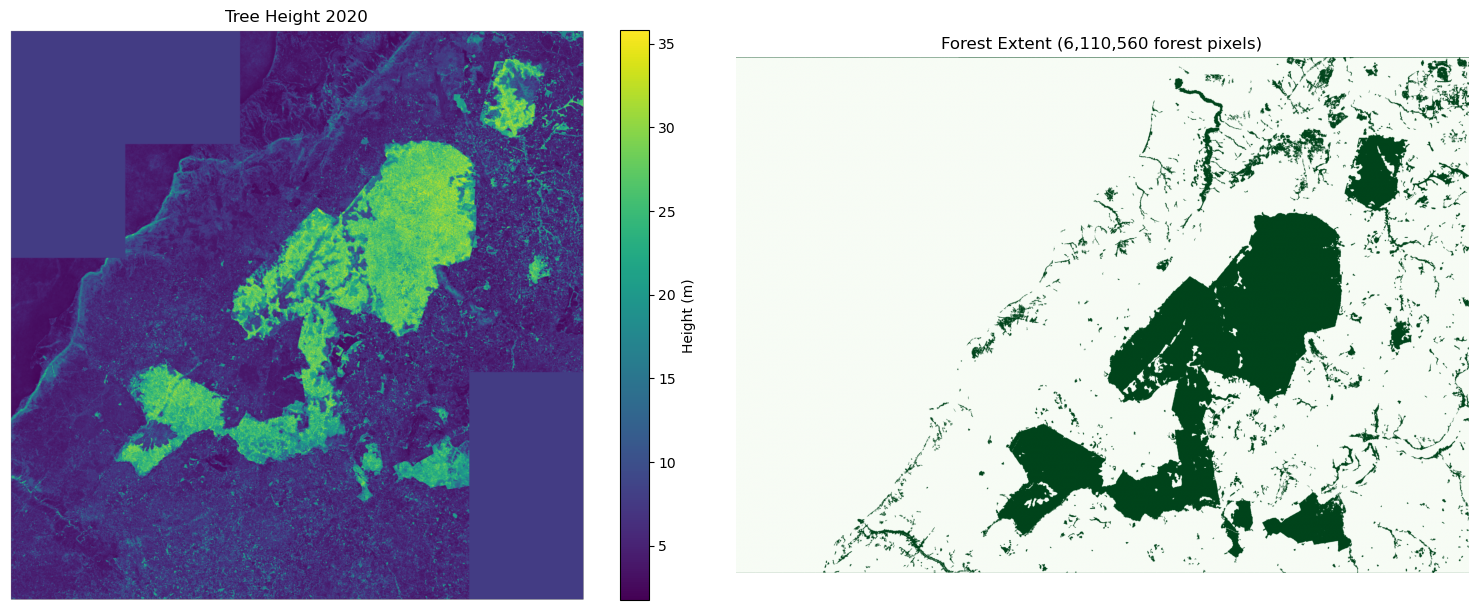

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Tree height
im1 = ax1.imshow(treeheight_data[2020], cmap='viridis')
ax1.set_title('Tree Height 2020')
ax1.axis('off')
plt.colorbar(im1, ax=ax1, label='Height (m)')

# Forest extent binary
forest_binary = forest_extent > 0
im2 = ax2.imshow(forest_binary, cmap='Greens')
ax2.set_title(f'Forest Extent ({forest_binary.sum():,} forest pixels)')
ax2.axis('off')

plt.tight_layout()
plt.show()

## Forest Baseline

In [16]:
from rasterio.warp import reproject, Resampling

# Resample forest extent to match tree height grid
with rasterio.open(treeheight_filepath) as src_th:
    with rasterio.open(forest_extent_path) as src_fe:
        forest_extent_resampled = np.empty(treeheight_data[2020].shape, dtype=src_fe.dtypes[0])
        
        reproject(
            source=rasterio.band(src_fe, 1),
            destination=forest_extent_resampled,
            src_transform=src_fe.transform,
            src_crs=src_fe.crs,
            dst_transform=src_th.transform,
            dst_crs=src_th.crs,
            resampling=Resampling.nearest
        )

# Create baseline
forest_baseline = (forest_extent_resampled > 0) & (treeheight_data[2020] > 5)

print(f"Forest baseline pixels: {np.sum(forest_baseline):,}")

Forest baseline pixels: 225,187


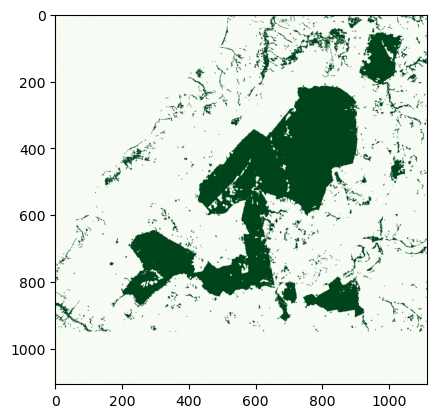

In [17]:
plt.imshow(forest_baseline, cmap='Greens')

# Deforestation progression

In [36]:
# Initialize deforestation map
# 0 = non-forest, 1 = stable forest, 20-24 = year of deforestation

defo_treeheight = 12

deforestation_map = np.zeros_like(treeheight_data[2020], dtype=int)

# Set initial values
deforestation_map[~forest_baseline] = 0  # Non-forest areas
deforestation_map[forest_baseline] = 1   # Initial forest

# Track deforestation year by year
years = [2021, 2022, 2023, 2024]

for year in years:
    # Find pixels that are still forest (value = 1) but height dropped below defo_treeheight (treeheight bias)
    still_forest = (deforestation_map == 1)
    height_dropped = (treeheight_data[year] < defo_treeheight)
    newly_deforested = still_forest & height_dropped
    
    # Mark with deforestation year (20, 21, 22, 23, 24)
    deforestation_map[newly_deforested] = year - 2000
    
    print(f"{year}: {np.sum(newly_deforested):,} pixels deforested")

# Summary
print(f"\nStable non-forest (0): {np.sum(deforestation_map == 0):,}")
print(f"Stable forest (1): {np.sum(deforestation_map == 1):,}")
print(f"Total deforested: {np.sum((deforestation_map >= 20) & (deforestation_map <= 24)):,}")

2021: 49,136 pixels deforested
2022: 14,406 pixels deforested
2023: 7,046 pixels deforested
2024: 6,769 pixels deforested

Stable non-forest (0): 1,008,011
Stable forest (1): 147,830
Total deforested: 77,357


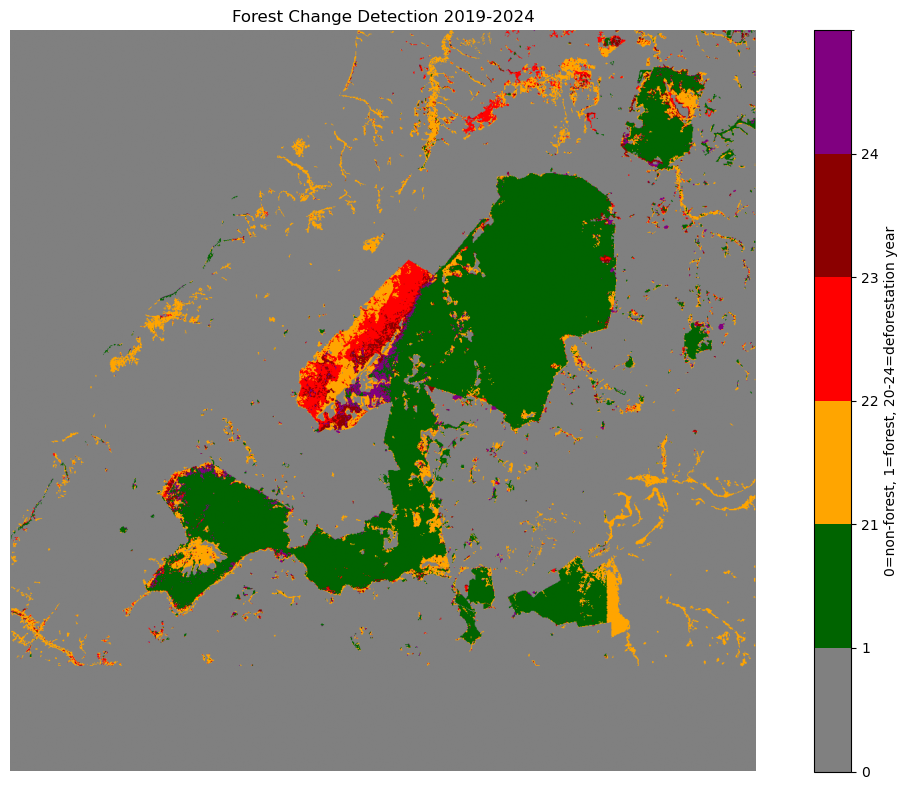

In [37]:
# Create colormap
plt.figure(figsize=(12, 8))

# Custom colors: gray (non-forest), green (forest), red gradient (deforestation years)
cmap = plt.cm.colors.ListedColormap(['gray', 'darkgreen', 'orange', 'red', 'darkred', 'black', 'purple'])
bounds = [0, 1, 21, 22, 23, 24, 25]
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

im = plt.imshow(deforestation_map, cmap=cmap, norm=norm)
plt.colorbar(im, label='0=non-forest, 1=forest, 20-24=deforestation year', ticks=[0, 1, 21, 22, 23, 24])
plt.title('Forest Change Detection 2019-2024')
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Export with LZW compression
output_path = Path.home() / "data/LEON_P6_forest-agri-change/tess_deforestation/deforestation_map_tess_2020_2024_18m.tif"

with rasterio.open(treeheight_filepath) as src:
    with rasterio.open(output_path, 'w', driver='GTiff', height=src.height, 
                       width=src.width, count=1, dtype='int16', crs=src.crs, 
                       transform=src.transform, compress='lzw') as dst:
        dst.write(deforestation_map, 1)

print(f"Saved: {output_path}")

Saved: /home/georg/data/LEON_P6_forest-agri-change/deforestation/deforestation_map_tess_2020_2024_11m.tif
